In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler,OrdinalEncoder,LabelEncoder,OneHotEncoder
from category_encoders import TargetEncoder

In [15]:
df=pd.read_csv('D:\machine_learning\Algorithms\Linear regression\employee_salary_regression.csv')

In [16]:
df

,employee_id,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,remote_work,annual_salary_usd
0,EMP0001,29,9,Master,Software Engineer,1,2.4,3,0,106343.31
1,EMP0002,27,6,Bachelor,ML Engineer,3,2.1,5,1,82852.60
2,EMP0003,36,13,Master,Data Analyst,1,4.1,7,1,142019.59
3,EMP0004,43,23,High School,DevOps,1,3.1,7,1,159972.80
4,EMP0005,24,1,High School,DevOps,1,3.7,12,1,94126.86
...,...,...,...,...,...,...,...,...,...,...
995,EMP0996,37,13,Master,ML Engineer,2,3.4,11,0,127579.68
996,EMP0997,27,5,PhD,Product Manager,3,4.5,6,1,96672.53
997,EMP0998,33,10,Bachelor,Software Engineer,3,4.2,9,1,107247.32
998,EMP0999,33,9,High School,DevOps,3,4.8,5,0,100412.67


In [17]:
df.drop(columns=['employee_id','remote_work'],inplace=True)

In [18]:
df.head()

,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,annual_salary_usd
0,29,9,Master,Software Engineer,1,2.4,3,106343.31
1,27,6,Bachelor,ML Engineer,3,2.1,5,82852.60
2,36,13,Master,Data Analyst,1,4.1,7,142019.59
3,43,23,High School,DevOps,1,3.1,7,159972.80
4,24,1,High School,DevOps,1,3.7,12,94126.86


In [19]:
x=df.drop(columns='annual_salary_usd')
y=df['annual_salary_usd']

In [20]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns

<Axes: >

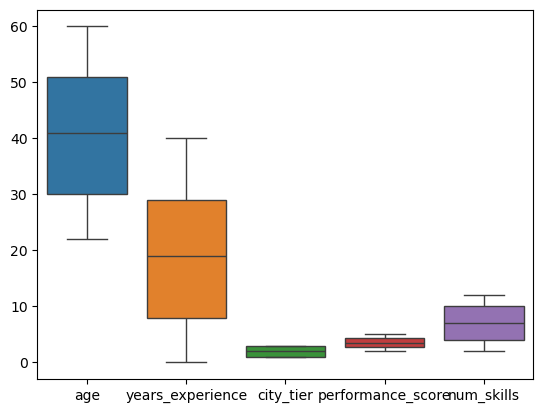

In [21]:
sns.boxplot(x[num_cols])

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [23]:
df.corr(numeric_only=True)

,age,years_experience,city_tier,performance_score,num_skills,annual_salary_usd
age,1.000000,0.992704,-0.050803,-0.015926,0.031856,0.939521
years_experience,0.992704,1.000000,-0.051587,-0.011547,0.034281,0.947786
city_tier,-0.050803,-0.051587,1.000000,0.035369,-0.010308,-0.240258
performance_score,-0.015926,-0.011547,0.035369,1.000000,-0.002240,0.140946
num_skills,0.031856,0.034281,-0.010308,-0.002240,1.000000,0.146429
annual_salary_usd,0.939521,0.947786,-0.240258,0.140946,0.146429,1.000000


# Scaling

In [24]:
scaler=MinMaxScaler()
x_train[num_cols]=scaler.fit_transform(x_train[num_cols])
x_train[num_cols]

,age,years_experience,city_tier,performance_score,num_skills
29,0.973684,0.900,1.0,0.066667,0.2
535,0.552632,0.575,0.5,0.366667,0.9
695,0.078947,0.075,0.0,0.466667,0.7
557,0.473684,0.425,1.0,0.833333,0.0
836,0.710526,0.725,0.5,0.500000,0.5
...,...,...,...,...,...
106,0.631579,0.625,0.0,0.500000,0.9
270,0.473684,0.475,0.0,0.366667,0.3
860,0.131579,0.100,1.0,0.966667,0.9
435,0.736842,0.675,0.5,0.466667,0.2


In [25]:
x_test[num_cols]=scaler.transform(x_test[num_cols])
x_test

,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills
521,0.921053,0.850,Bachelor,Product Manager,1.0,0.566667,0.4
737,0.210526,0.250,High School,Product Manager,0.0,0.100000,0.7
740,0.763158,0.725,High School,QA Engineer,0.5,0.733333,0.3
660,0.026316,0.000,Master,QA Engineer,0.0,0.333333,0.3
411,0.763158,0.775,Master,QA Engineer,0.0,0.266667,0.7
...,...,...,...,...,...,...,...
408,0.500000,0.450,Master,Product Manager,1.0,0.433333,1.0
332,0.210526,0.150,Bachelor,ML Engineer,1.0,0.433333,0.0
208,0.342105,0.275,PhD,ML Engineer,1.0,0.033333,1.0
613,0.631579,0.625,PhD,ML Engineer,1.0,0.100000,0.5


In [26]:
x_train[obj_cols]

,education_level,job_role
29,Bachelor,Data Analyst
535,Bachelor,DevOps
695,High School,Data Analyst
557,Bachelor,Software Engineer
836,Bachelor,QA Engineer
...,...,...
106,PhD,Data Analyst
270,Bachelor,Product Manager
860,PhD,DevOps
435,High School,ML Engineer


In [27]:
x_train[obj_cols].nunique()

education_level    4
job_role           6
dtype: int64

In [28]:
obj_cols

Index(['education_level', 'job_role'], dtype='object')

# Encoding

* Since we have same order in education level we will use ordinal encoder and for non ordinal column job role we use OneHot encoder

In [29]:
# Using ordinal nencoder for education_level column
ordinal_encoder=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1,categories=[['High School','Bachelor','Master','PhD']])
x_train['education_level']=ordinal_encoder.fit_transform(x_train[['education_level']])
x_test['education_level']=ordinal_encoder.transform(x_test[['education_level']])

In [30]:
# Using one hot encoder for job_role column cause its not ordinal
ohe=OneHotEncoder(handle_unknown='ignore',sparse_output=False)
xtrain_values=ohe.fit_transform(x_train[['job_role']])
cols=ohe.get_feature_names_out()
cols

array(['job_role_Data Analyst', 'job_role_DevOps', 'job_role_ML Engineer',
       'job_role_Product Manager', 'job_role_QA Engineer',
       'job_role_Software Engineer'], dtype=object)

In [31]:
x_train[cols]=xtrain_values
x_train

,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,job_role_Data Analyst,job_role_DevOps,job_role_ML Engineer,job_role_Product Manager,job_role_QA Engineer,job_role_Software Engineer
29,0.973684,0.900,1.0,Data Analyst,1.0,0.066667,0.2,1.0,0.0,0.0,0.0,0.0,0.0
535,0.552632,0.575,1.0,DevOps,0.5,0.366667,0.9,0.0,1.0,0.0,0.0,0.0,0.0
695,0.078947,0.075,0.0,Data Analyst,0.0,0.466667,0.7,1.0,0.0,0.0,0.0,0.0,0.0
557,0.473684,0.425,1.0,Software Engineer,1.0,0.833333,0.0,0.0,0.0,0.0,0.0,0.0,1.0
836,0.710526,0.725,1.0,QA Engineer,0.5,0.500000,0.5,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.631579,0.625,3.0,Data Analyst,0.0,0.500000,0.9,1.0,0.0,0.0,0.0,0.0,0.0
270,0.473684,0.475,1.0,Product Manager,0.0,0.366667,0.3,0.0,0.0,0.0,1.0,0.0,0.0
860,0.131579,0.100,3.0,DevOps,1.0,0.966667,0.9,0.0,1.0,0.0,0.0,0.0,0.0
435,0.736842,0.675,0.0,ML Engineer,0.5,0.466667,0.2,0.0,0.0,1.0,0.0,0.0,0.0


In [32]:
x_train.drop(columns='job_role',inplace=True)
x_train

,age,years_experience,education_level,city_tier,performance_score,num_skills,job_role_Data Analyst,job_role_DevOps,job_role_ML Engineer,job_role_Product Manager,job_role_QA Engineer,job_role_Software Engineer
29,0.973684,0.900,1.0,1.0,0.066667,0.2,1.0,0.0,0.0,0.0,0.0,0.0
535,0.552632,0.575,1.0,0.5,0.366667,0.9,0.0,1.0,0.0,0.0,0.0,0.0
695,0.078947,0.075,0.0,0.0,0.466667,0.7,1.0,0.0,0.0,0.0,0.0,0.0
557,0.473684,0.425,1.0,1.0,0.833333,0.0,0.0,0.0,0.0,0.0,0.0,1.0
836,0.710526,0.725,1.0,0.5,0.500000,0.5,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.631579,0.625,3.0,0.0,0.500000,0.9,1.0,0.0,0.0,0.0,0.0,0.0
270,0.473684,0.475,1.0,0.0,0.366667,0.3,0.0,0.0,0.0,1.0,0.0,0.0
860,0.131579,0.100,3.0,1.0,0.966667,0.9,0.0,1.0,0.0,0.0,0.0,0.0
435,0.736842,0.675,0.0,0.5,0.466667,0.2,0.0,0.0,1.0,0.0,0.0,0.0


In [33]:
xtest_values=ohe.transform(x_test[['job_role']])
x_test[cols]=xtest_values
x_test

,age,years_experience,education_level,job_role,city_tier,performance_score,num_skills,job_role_Data Analyst,job_role_DevOps,job_role_ML Engineer,job_role_Product Manager,job_role_QA Engineer,job_role_Software Engineer
521,0.921053,0.850,1.0,Product Manager,1.0,0.566667,0.4,0.0,0.0,0.0,1.0,0.0,0.0
737,0.210526,0.250,0.0,Product Manager,0.0,0.100000,0.7,0.0,0.0,0.0,1.0,0.0,0.0
740,0.763158,0.725,0.0,QA Engineer,0.5,0.733333,0.3,0.0,0.0,0.0,0.0,1.0,0.0
660,0.026316,0.000,2.0,QA Engineer,0.0,0.333333,0.3,0.0,0.0,0.0,0.0,1.0,0.0
411,0.763158,0.775,2.0,QA Engineer,0.0,0.266667,0.7,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.500000,0.450,2.0,Product Manager,1.0,0.433333,1.0,0.0,0.0,0.0,1.0,0.0,0.0
332,0.210526,0.150,1.0,ML Engineer,1.0,0.433333,0.0,0.0,0.0,1.0,0.0,0.0,0.0
208,0.342105,0.275,3.0,ML Engineer,1.0,0.033333,1.0,0.0,0.0,1.0,0.0,0.0,0.0
613,0.631579,0.625,3.0,ML Engineer,1.0,0.100000,0.5,0.0,0.0,1.0,0.0,0.0,0.0


In [34]:
x_test.drop(columns='job_role',inplace=True)
x_test

,age,years_experience,education_level,city_tier,performance_score,num_skills,job_role_Data Analyst,job_role_DevOps,job_role_ML Engineer,job_role_Product Manager,job_role_QA Engineer,job_role_Software Engineer
521,0.921053,0.850,1.0,1.0,0.566667,0.4,0.0,0.0,0.0,1.0,0.0,0.0
737,0.210526,0.250,0.0,0.0,0.100000,0.7,0.0,0.0,0.0,1.0,0.0,0.0
740,0.763158,0.725,0.0,0.5,0.733333,0.3,0.0,0.0,0.0,0.0,1.0,0.0
660,0.026316,0.000,2.0,0.0,0.333333,0.3,0.0,0.0,0.0,0.0,1.0,0.0
411,0.763158,0.775,2.0,0.0,0.266667,0.7,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.500000,0.450,2.0,1.0,0.433333,1.0,0.0,0.0,0.0,1.0,0.0,0.0
332,0.210526,0.150,1.0,1.0,0.433333,0.0,0.0,0.0,1.0,0.0,0.0,0.0
208,0.342105,0.275,3.0,1.0,0.033333,1.0,0.0,0.0,1.0,0.0,0.0,0.0
613,0.631579,0.625,3.0,1.0,0.100000,0.5,0.0,0.0,1.0,0.0,0.0,0.0


In [35]:
model=LinearRegression()
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
ytrain_pred=model.predict(x_train)

In [37]:
ytest_pred=model.predict(x_test)

In [38]:
y_train-ytrain_pred

29    -2315.436233
535    5457.658850
695   -2656.802589
557    1703.608391
836   -3497.625154
          ...     
106    6455.519860
270   -7011.662718
860   -3108.499085
435    -996.154351
102    5642.284863
Name: annual_salary_usd, Length: 800, dtype: float64

In [39]:
model.score(x_train,y_train)

0.9838296394813364

In [40]:
model.score(x_test,y_test)

0.9837814573026543

In [41]:
model.predict([[25,5,3,3,4,5,0,1,0,0,0,0]]) # same as the previous the value is too high

c:\Users\mural\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([779786.90068948])

In [42]:
model.predict([[0.75,0.65,2,2,0.7,0.8,1,1,1,1,1,1]])

c:\Users\mural\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([143109.98793329])